<h1><center><font color=magenta face=georgia>Credit Card Customer Segmentation</font></center></h1>
<b>Dataset link : </b><a href="https://www.kaggle.com/code/des137/customer-segmentation-credit-cards/input?select=CC+GENERAL.csv">Kaggle dataset</a><br>
<p style="font-family: verdona;">
<b>Data Overview</b>
<pre><p style="font-family: verdona;">
<b>CUST_ID : </b>Identification of Credit Card holder (Categorical)
-------------------------------------------------------------------------------------------------------------------
<b>BALANCE : </b>Balance amount left in their account to make purchases
-------------------------------------------------------------------------------------------------------------------
<b>BALANCE_FREQUENCY : </b>How frequently the Balance is updated, score between 0 and 1 (1 = frequently updated, 
0 = not frequently updated)
-------------------------------------------------------------------------------------------------------------------
<b>PURCHASES : </b>Amount of purchases made from account
-------------------------------------------------------------------------------------------------------------------
<b>ONEOFF_PURCHASES : </b>Maximum purchase amount done in one-go
-------------------------------------------------------------------------------------------------------------------
<b>INSTALLMENTS_PURCHASES : </b>Amount of purchase done in installment
-------------------------------------------------------------------------------------------------------------------
<b>CASH_ADVANCE : </b>Cash in advance given by the user
-------------------------------------------------------------------------------------------------------------------
<b>PURCHASES_FREQUENCY : </b>How frequently the Purchases are being made, score between 0 and 1 (1 = frequently 
purchased, 0 = not frequently purchased)
-------------------------------------------------------------------------------------------------------------------
<b>ONEOFFPURCHASESFREQUENCY : </b>How frequently Purchases are happening in one-go (1 = frequently purchased, 
0 = not frequently purchased)
-------------------------------------------------------------------------------------------------------------------
<b>PURCHASESINSTALLMENTSFREQUENCY :</b> How frequently purchases in installments are being done (1 = frequently done,
0 = not frequently done)
-------------------------------------------------------------------------------------------------------------------
<b>CASHADVANCEFREQUENCY : </b>How frequently the cash in advance being paid
-------------------------------------------------------------------------------------------------------------------
<b>CASHADVANCETRX : </b>Number of Transactions made with "Cash in Advanced"
-------------------------------------------------------------------------------------------------------------------
<b>PURCHASES_TRX : </b>Numbe of purchase transactions made
-------------------------------------------------------------------------------------------------------------------
<b>CREDIT_LIMIT : </b>Limit of Credit Card for user
-------------------------------------------------------------------------------------------------------------------
<b>PAYMENTS : </b>Amount of Payment done by user
-------------------------------------------------------------------------------------------------------------------
<b>MINIMUM_PAYMENTS : </b>Minimum amount of payments made by user
-------------------------------------------------------------------------------------------------------------------
<b>PRCFULLPAYMENT :</b> Percent of full payment paid by user
-------------------------------------------------------------------------------------------------------------------
<b>TENURE :</b> Tenure of credit card service for user

<center><font color=magenta face=georgia><h1>Importing Libraries

In [1]:
#============================================= preprocessing libraries =================================================
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
import warnings


#============================================= visualization libraries ==================================================
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
from IPython.display import Image, display


#============================================= statistical libraries ====================================================
import numpy as np


#============================================ clustering models, evaluation libraries ====================================
import scipy.cluster.hierarchy as sch
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

#============================================ Pipeline libraries =========================================================
import joblib
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline

<center><font color=magenta face=georgia><h1>Importing Data

In [2]:
df = pd.read_csv('datasets/Customer Data.csv')
print(df.shape)
df.head()

(8950, 18)


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

<center><h1><font face=georgia color=magenta>Data Cleaning and Preprocessing

In [4]:
len(df) == len(df.CUST_ID.unique())

True

<h4><font face=verdona><hr>Dropping ID column as all of the values are unique and doesn't bring any value to the data<hr>

In [5]:
df.drop(columns=['CUST_ID'], inplace=True)

<h4><font face=verdona><hr>Dropping duplicate records<hr>

In [6]:
df.duplicated().sum()

np.int64(0)

<h4><font face=verdona><hr>Handling Missing values<hr>

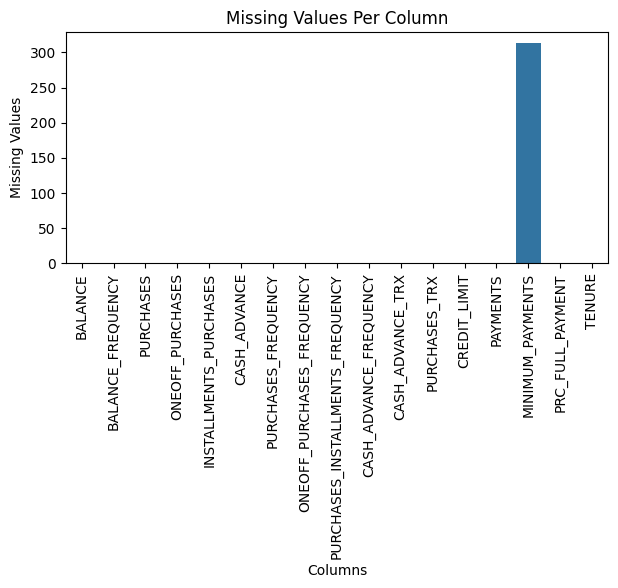

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,3))
missing_values = df.isnull().sum()  
sns.barplot(x=missing_values.index, y=missing_values.values)  
plt.xticks(rotation=90)
plt.xlabel("Columns")
plt.ylabel("Missing Values")
plt.title("Missing Values Per Column")
plt.show()


<h4><font face=verdona><hr>We can drop the missing records as the number of missing records is minimal<hr>

In [ ]:
df.dropna(inplace=True)

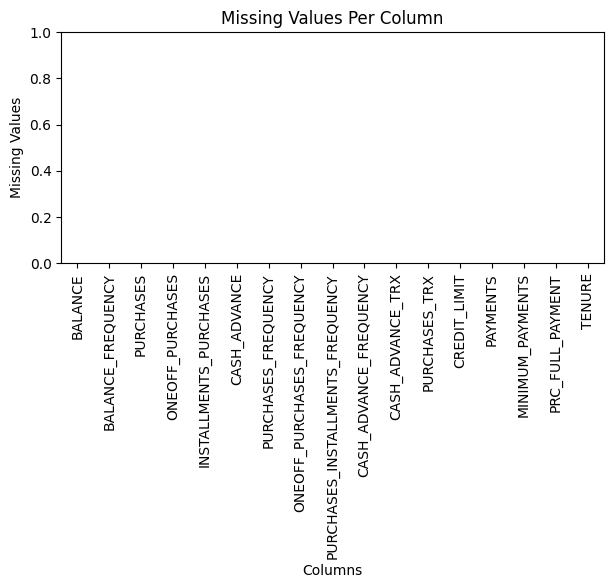

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,3))
missing_values = df.isnull().sum()  
sns.barplot(x=missing_values.index, y=missing_values.values)  
plt.xticks(rotation=90)
plt.ylim(0, missing_values.values.max() + 1)
plt.xlabel("Columns")
plt.ylabel("Missing Values")
plt.title("Missing Values Per Column")
plt.show()

<h4><font face=verdona><hr>Data in entirely Numeric, thus encoding is not required<hr>

<center><h1><font face=georgia color=magenta>EDA

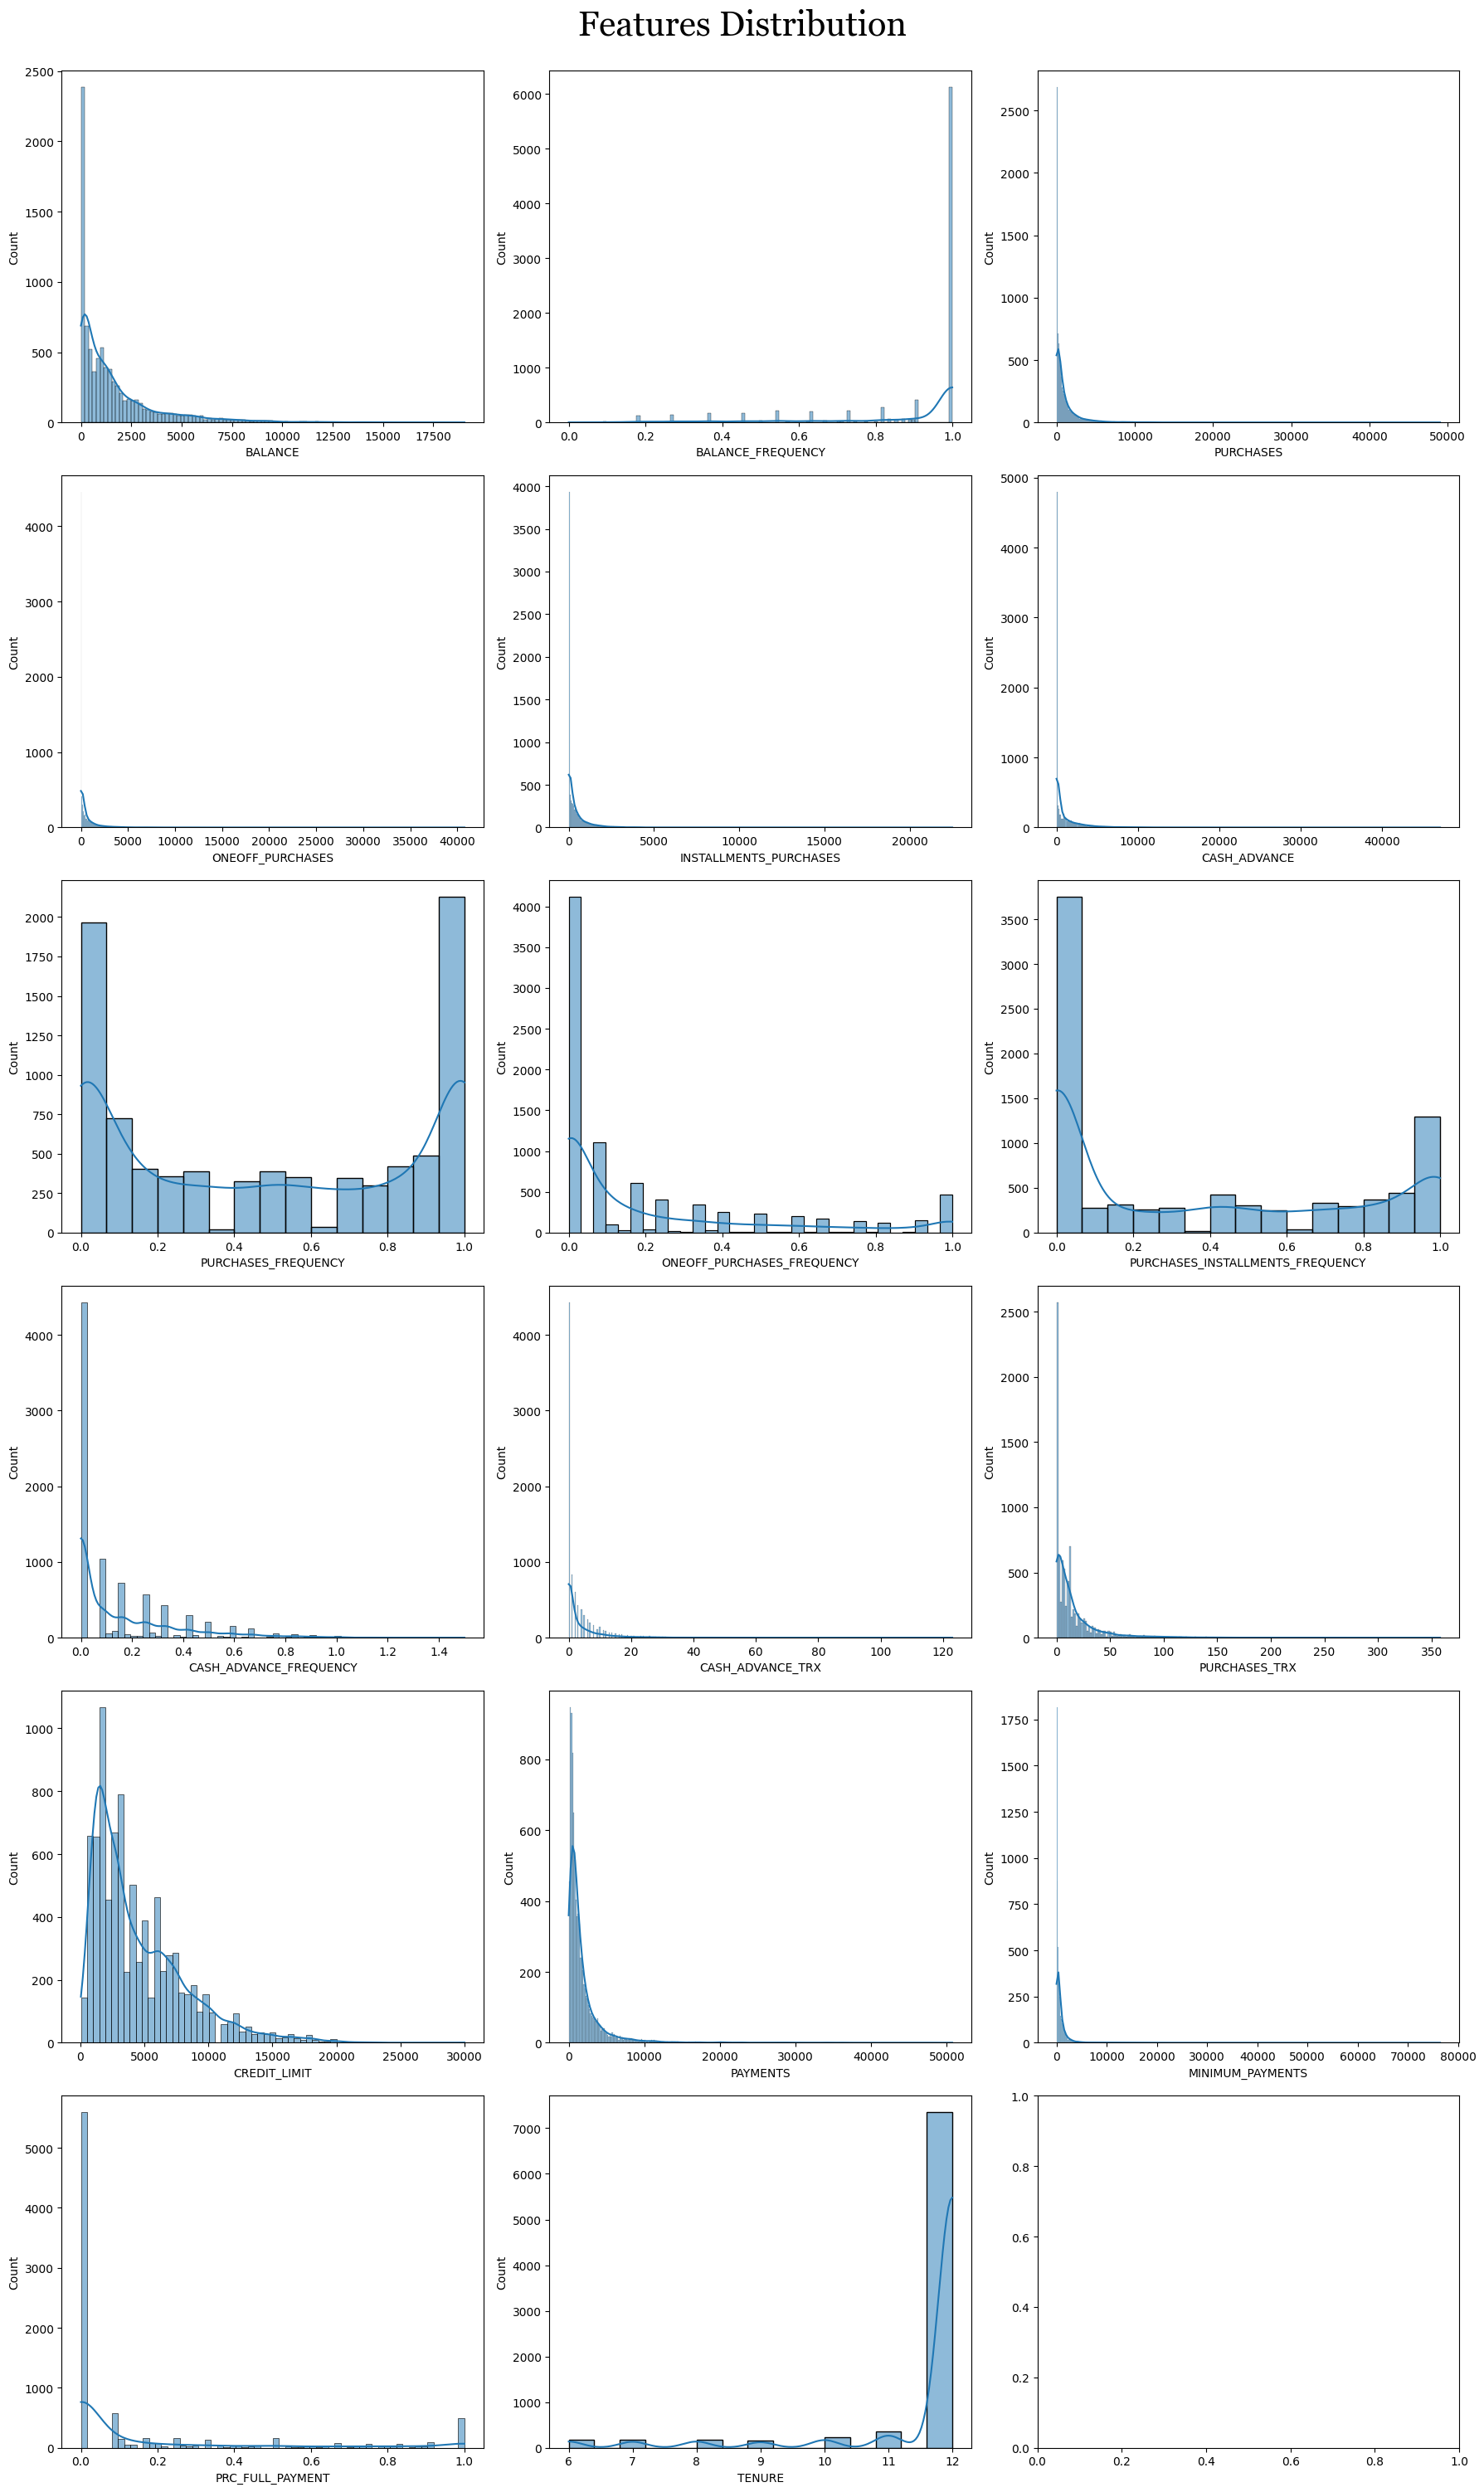

In [10]:
fig, ax = plt.subplots(ncols=3, nrows=round((len(df.columns)+1)/3), figsize=(18,5*round((len(df.columns)+1)/3)))
axes = ax.flatten()

for index, col in enumerate(df.columns):
    sns.histplot(df[col], kde=True, ax=axes[index])
plt.suptitle('Features Distribution', font='georgia', fontsize=30, y=1)
plt.tight_layout()
plt.show()

<h4><font face=verdona><hr>Normalization using Log <hr>
As the data is skewed I will use Log transformation to Normalize the data

In [11]:
log_cols = list()
for col in df.columns:
    if (not(df[col].min() == 0 and df[col].max() == 1) and (col!='TENURE')) :
        log_cols.append(col)

log_cols

['BALANCE',
 'PURCHASES',
 'ONEOFF_PURCHASES',
 'INSTALLMENTS_PURCHASES',
 'CASH_ADVANCE',
 'CASH_ADVANCE_FREQUENCY',
 'CASH_ADVANCE_TRX',
 'PURCHASES_TRX',
 'CREDIT_LIMIT',
 'PAYMENTS',
 'MINIMUM_PAYMENTS']

In [12]:
log_transformed_df = df.copy()
for col in log_transformed_df:
        log_transformed_df[col] = np.log(1 + log_transformed_df[col])

# log_transformed_df['TENURE'] = log_transformed_df['TENURE'].astype(int)
print(log_transformed_df.shape)
log_transformed_df.head()

(8636, 17)


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,3.735304,0.597837,4.568506,0.000000,4.568506,0.000000,0.154151,0.000000,0.080042,0.000000,0.000000,1.098612,6.908755,5.312231,4.945277,0.000000,2.564949
1,8.071989,0.646627,0.000000,0.000000,0.000000,8.770896,0.000000,0.000000,0.000000,0.223144,1.609438,0.000000,8.853808,8.319725,6.978531,0.200671,2.564949
2,7.822504,0.693147,6.651791,6.651791,0.000000,0.000000,0.693147,0.693147,0.000000,0.000000,0.000000,2.564949,8.922792,6.434654,6.442994,0.000000,2.564949
4,6.707735,0.693147,2.833213,2.833213,0.000000,0.000000,0.080042,0.080042,0.000000,0.000000,0.000000,0.693147,7.090910,6.521114,5.504483,0.000000,2.564949
5,7.501540,0.693147,7.196147,0.000000,7.196147,0.000000,0.510826,0.000000,0.459532,0.000000,0.000000,2.197225,7.496097,7.244983,7.786654,0.000000,2.564949


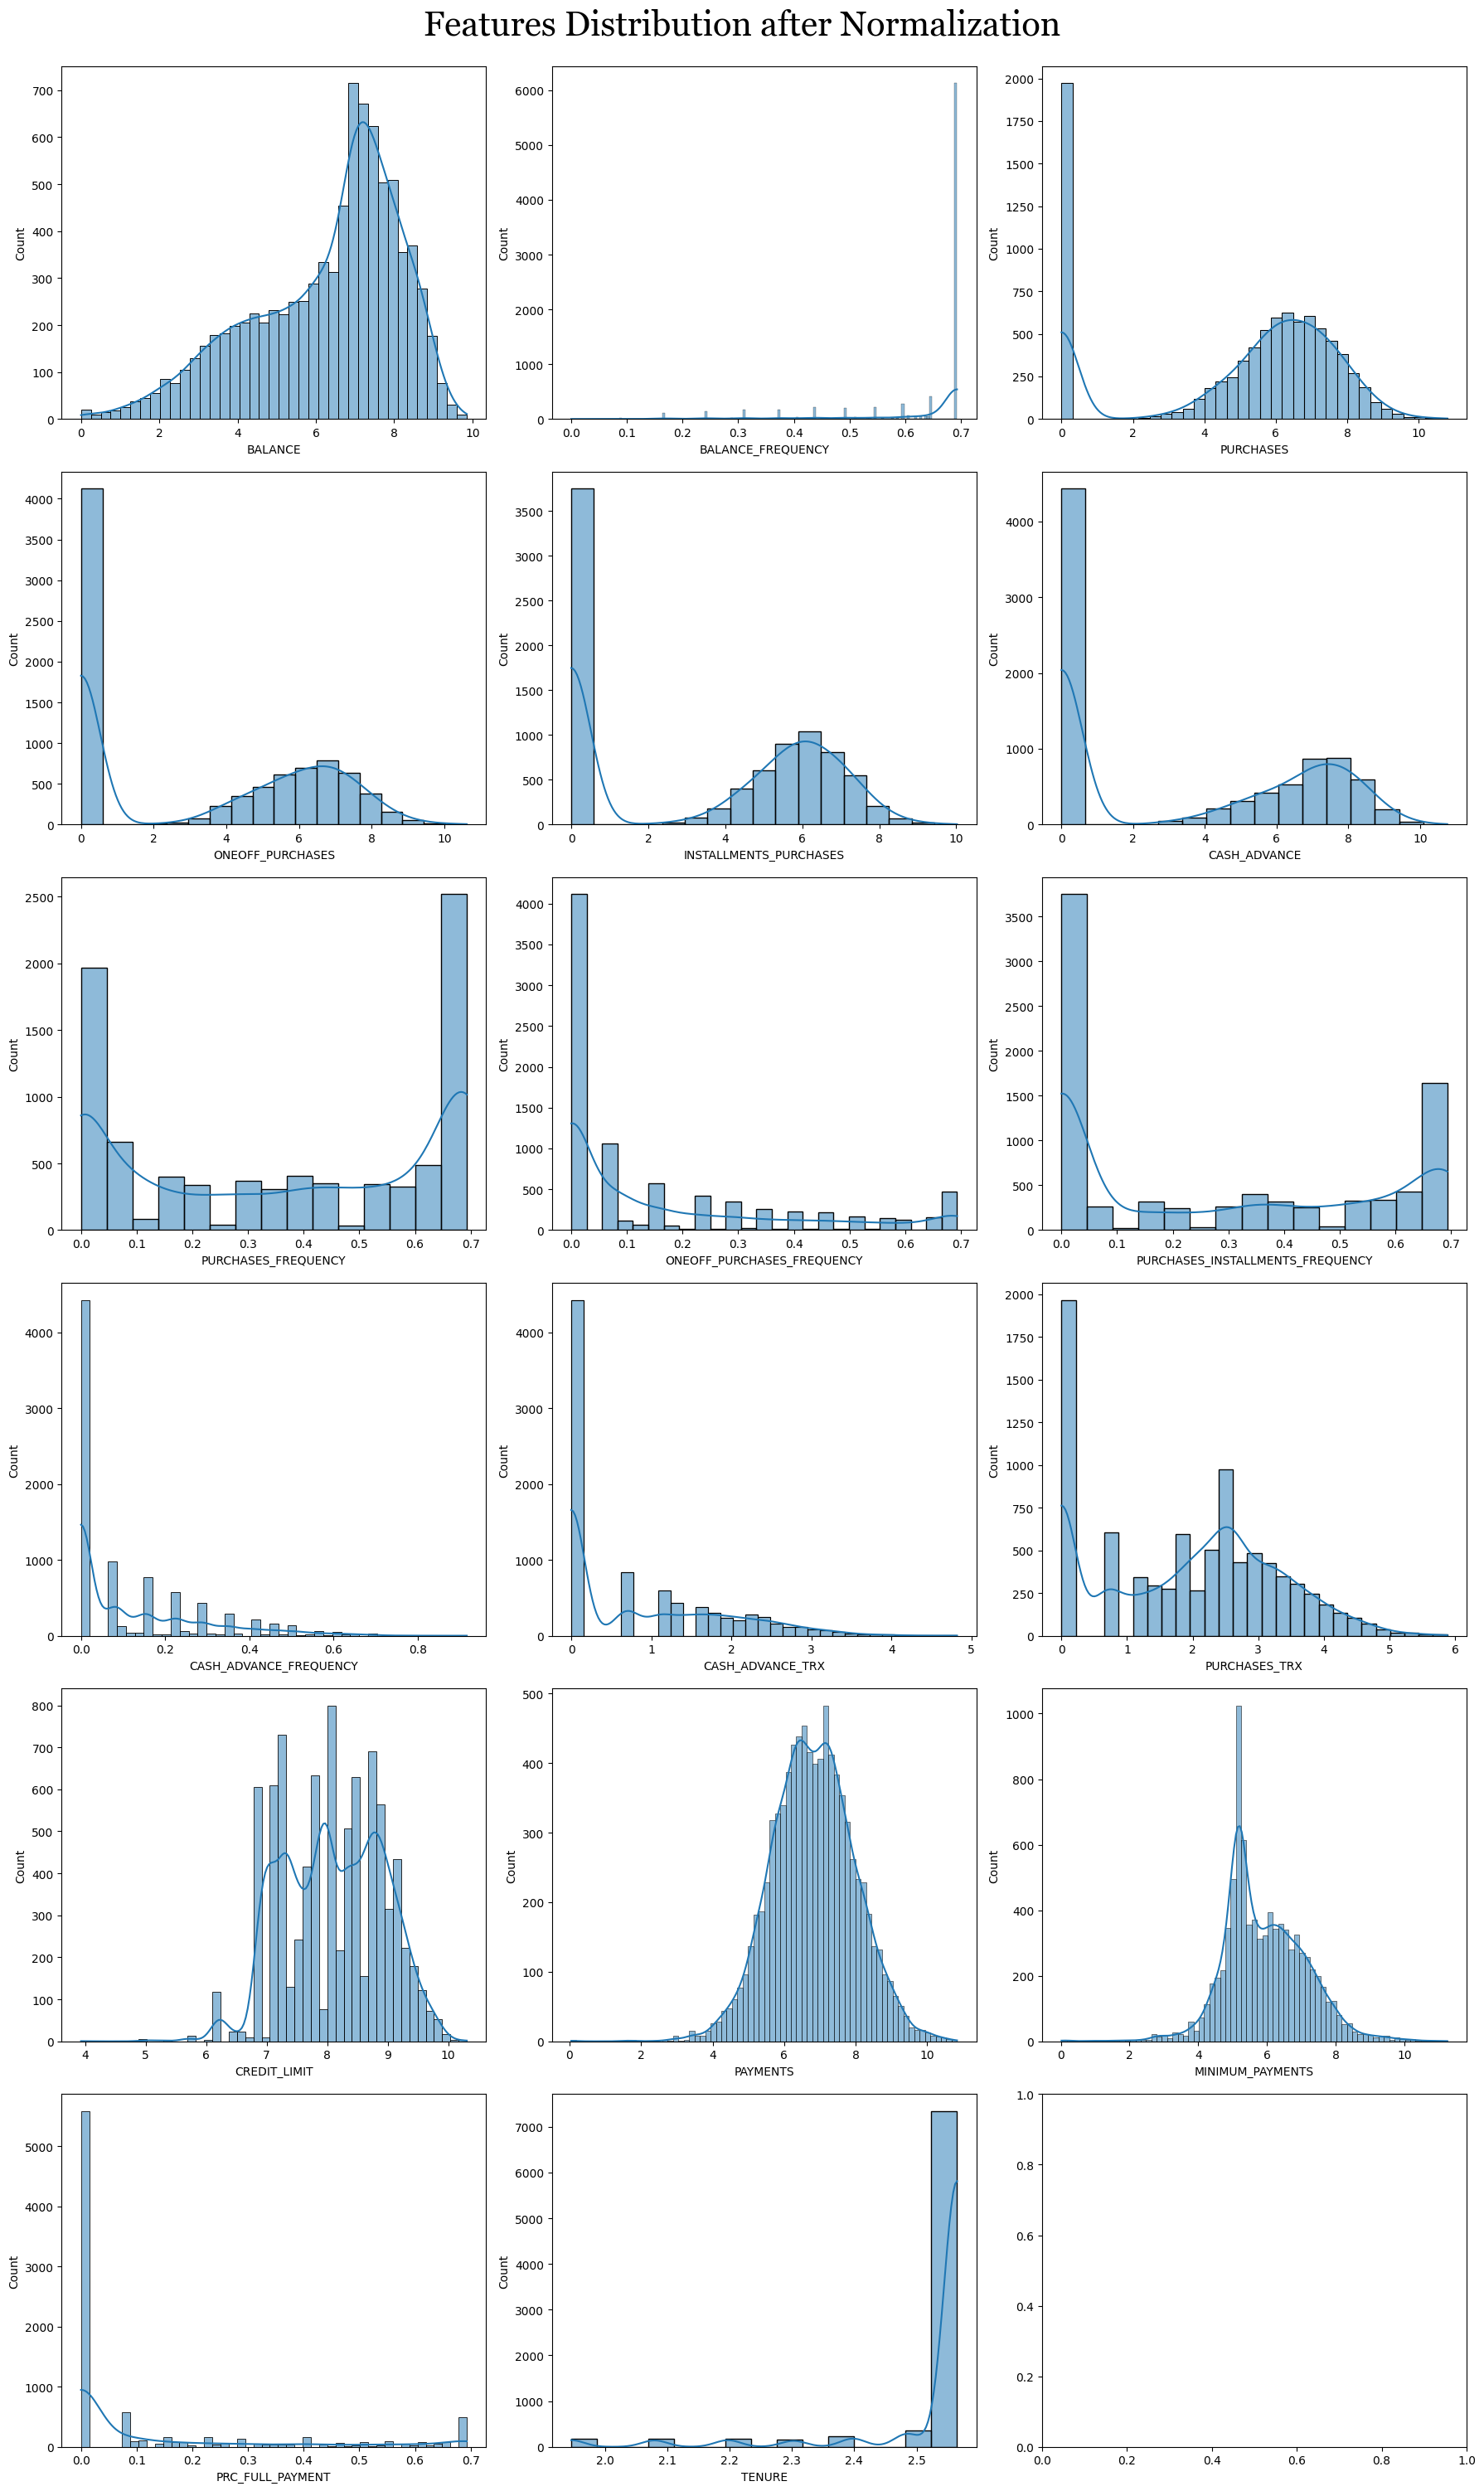

In [13]:
fig, ax = plt.subplots(ncols=3, nrows=round((len(log_transformed_df.columns)+1)/3), 
                       figsize=(18,5*round((len(log_transformed_df.columns)+1)/3)))
axes = ax.flatten()

for index, col in enumerate(log_transformed_df.columns):
    sns.histplot(log_transformed_df[col], kde=True, ax=axes[index])
plt.suptitle('Features Distribution after Normalization', font='georgia', fontsize=30, y=1)
plt.tight_layout()
plt.show()

In [15]:
def lb_ub(data, col):
    upper_b = np.percentile(data[col], 99.7)
    lower_b = np.percentile(data[col], 0.3)
    return lower_b, upper_b

lb_values = []
ub_values = []

for feature in df.columns:
    lb, ub = lb_ub(df, feature)
    lb_values.append(lb)
    ub_values.append(ub)

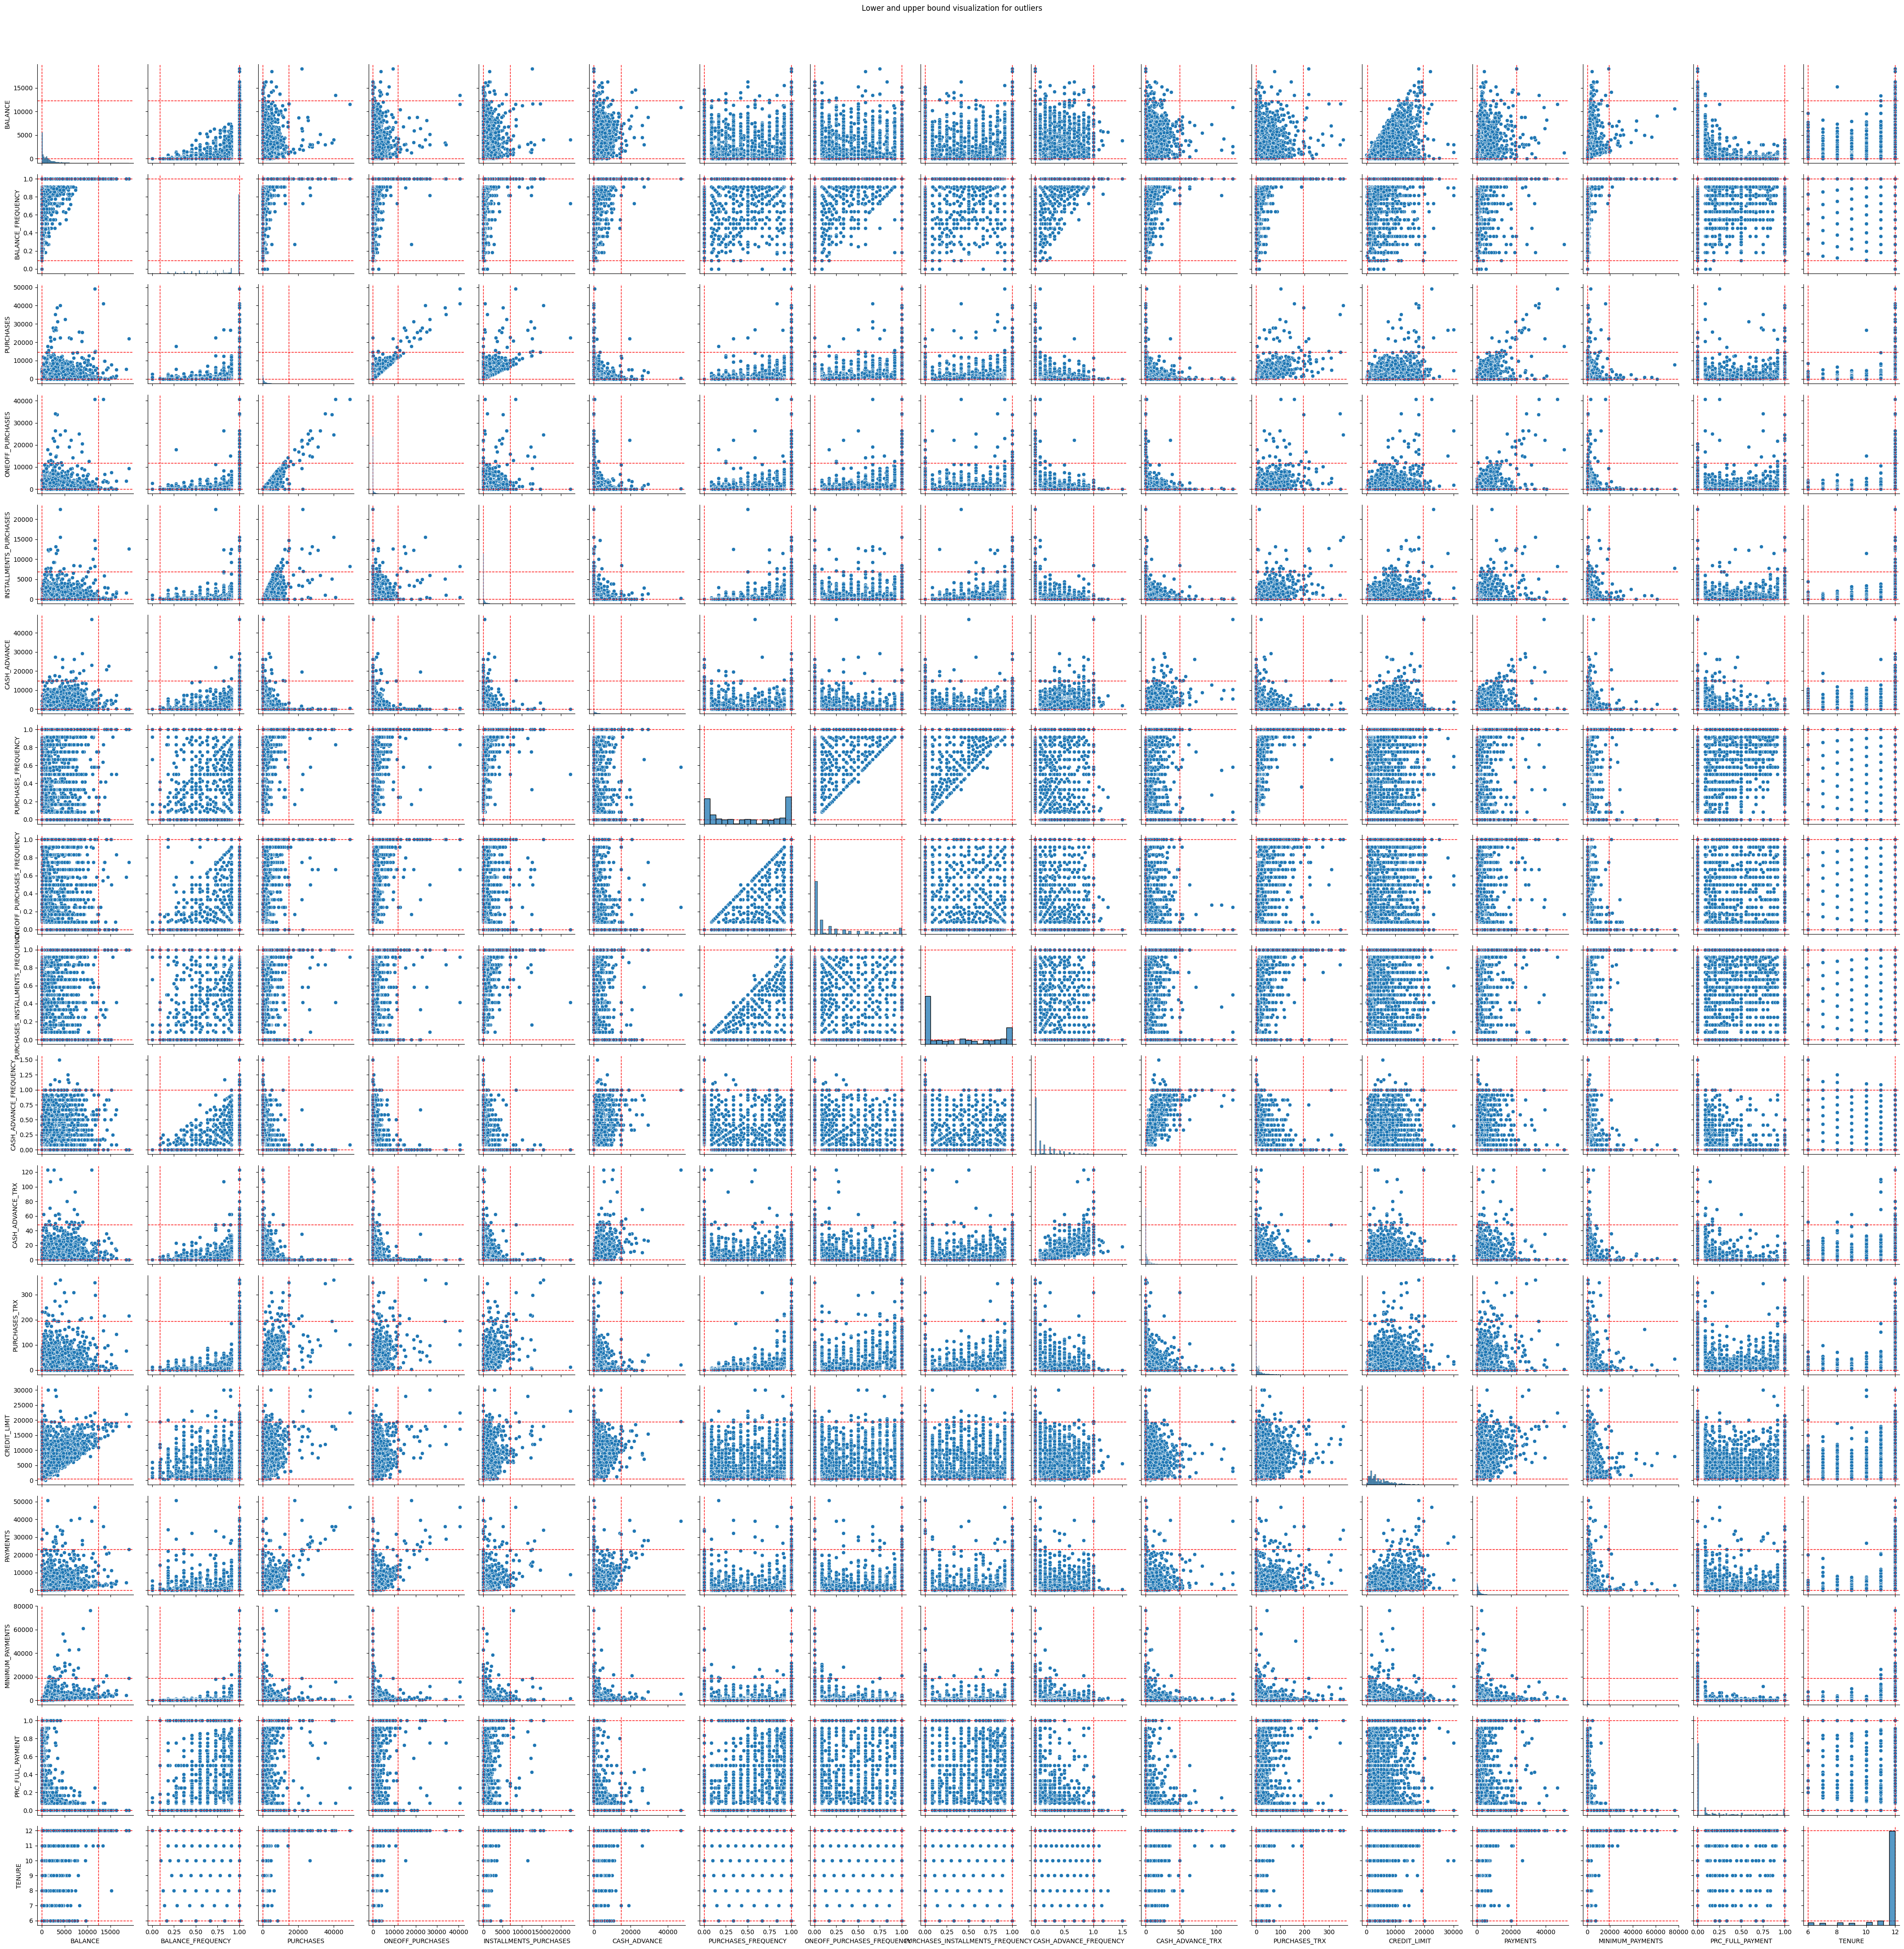

In [16]:
pairplot = sns.pairplot(df)
plt.suptitle('Lower and upper bound visualization for outliers', y=1.02) 
for row in range(len(df.columns)):
    for col in range(len(df.columns)):
        pairplot.axes[row, col].axvline(x=lb_values[col], color='red', linestyle='--', linewidth=1)
        pairplot.axes[row, col].axvline(x=ub_values[col], color='red', linestyle='--', linewidth=1)
        pairplot.axes[row, col].axhline(y=lb_values[row], color='red', linestyle='--', linewidth=1)
        pairplot.axes[row, col].axhline(y=ub_values[row], color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

<h4><font face=verdona><hr>Outlier Handling <hr>The data seems to have quite a few outliers but the outliers cannot be capped or trimmed as they might belong to a 
cluster

<h4><font face=verdona><hr>Handling Multi-collinearity<hr>

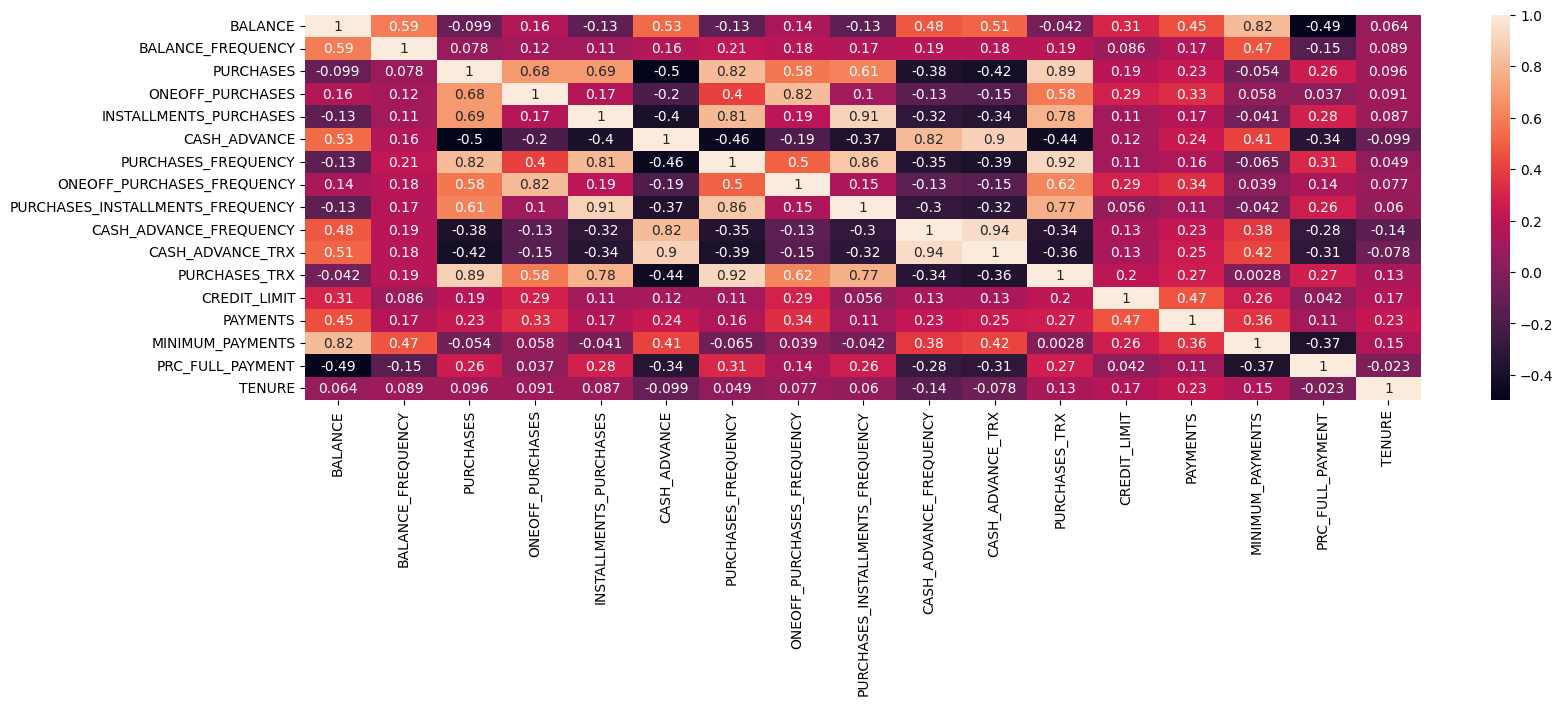

In [17]:
plt.figure(figsize=(18,5))
sns.heatmap(log_transformed_df.corr(), annot=True)
plt.show()

In [18]:
correlation_matrix = log_transformed_df.corr()

threshold = 0.9
highly_correlated_pairs = []

for i, col in enumerate(log_transformed_df.columns):
    for j in range(i + 1, len(log_transformed_df.columns)):
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            highly_correlated_pairs.append((col, log_transformed_df.columns[j]))

new_s = set()
print("Pairs of columns with high correlation:")
for col1, col2 in highly_correlated_pairs:
    print(f"{col1} and {col2}: {correlation_matrix.loc[col1, col2]}")
    # new_s.add(col1)
    new_s.add(col2) 

Pairs of columns with high correlation:
INSTALLMENTS_PURCHASES and PURCHASES_INSTALLMENTS_FREQUENCY: 0.9063820208314246
PURCHASES_FREQUENCY and PURCHASES_TRX: 0.9216305312196363
CASH_ADVANCE_FREQUENCY and CASH_ADVANCE_TRX: 0.9375478996731024


In [19]:
data_new = log_transformed_df.drop(columns=list(new_s))

<h4><font face=verdona><hr>Using Explained Variance to determine the number of components<hr>

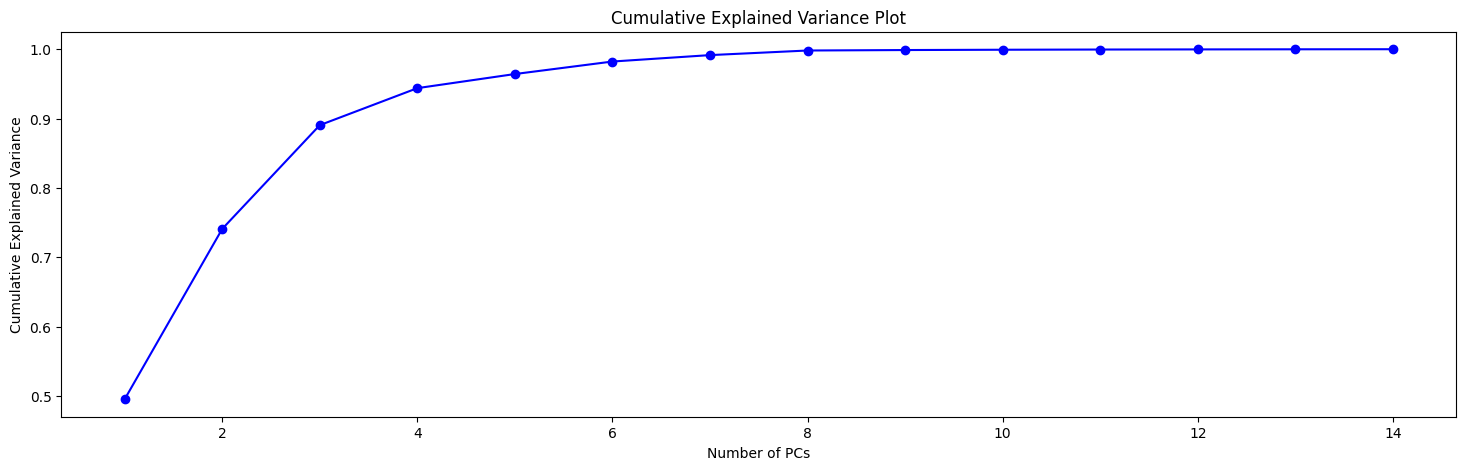

In [20]:
pca = PCA()
scaler = MinMaxScaler()
# scaled_df = scaler.fit_transform(data_new)
pca.fit(data_new)
cumulative_variance = pca.explained_variance_ratio_.cumsum()

plt.figure(figsize=(18, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'bo-')
plt.xlabel('Number of PCs')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance Plot')
plt.show()

In [21]:
cumulative_variance_threshold = 0.95
num_components = np.argmax(cumulative_variance >= cumulative_variance_threshold) 
num_components

np.int64(4)

In [22]:
scaler = MinMaxScaler()
pca = PCA(n_components=num_components)

In [23]:
# scaled_df = scaler.fit_transform(data_new)
pca_df = pca.fit_transform(data_new)
df_new = pd.DataFrame(pca_df)
df_new.head()

,0,1,2,3
0,-1.131391,-5.638595,0.437543,-0.501883
1,8.794180,1.315369,0.903667,0.783105
2,-2.468392,1.561188,-4.918480,2.475433
3,1.080909,-2.505522,-3.924572,2.183300
4,-3.266490,-2.807996,3.897840,3.193681


<h4><font face=verdona><hr>Using elbow method to determine the optimal number of clusters<hr>

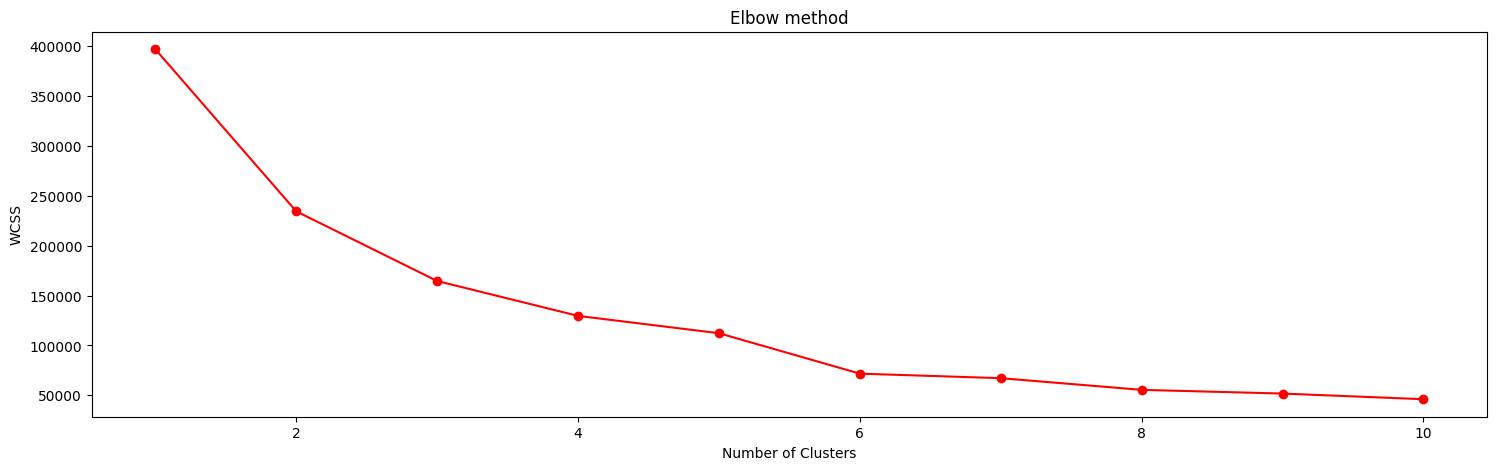

In [24]:
from sklearn.cluster import KMeans
warnings.filterwarnings('ignore')
kmeans_models = [KMeans(n_clusters=k,init='k-means++', random_state=42).fit(df_new) for k in range(1, 11)]
innertia = [model.inertia_ for model in kmeans_models]

plt.figure(figsize=(18,5))
plt.plot(range(1, 11), innertia, "ro-")
plt.title('Elbow method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [25]:
innertia

[396837.6692597793,
 234424.9884516497,
 164608.52116621856,
 129638.34878167181,
 112290.78472532058,
 71765.81684161094,
 67234.5038652657,
 55528.07598144431,
 51821.06801225238,
 46143.40840008792]

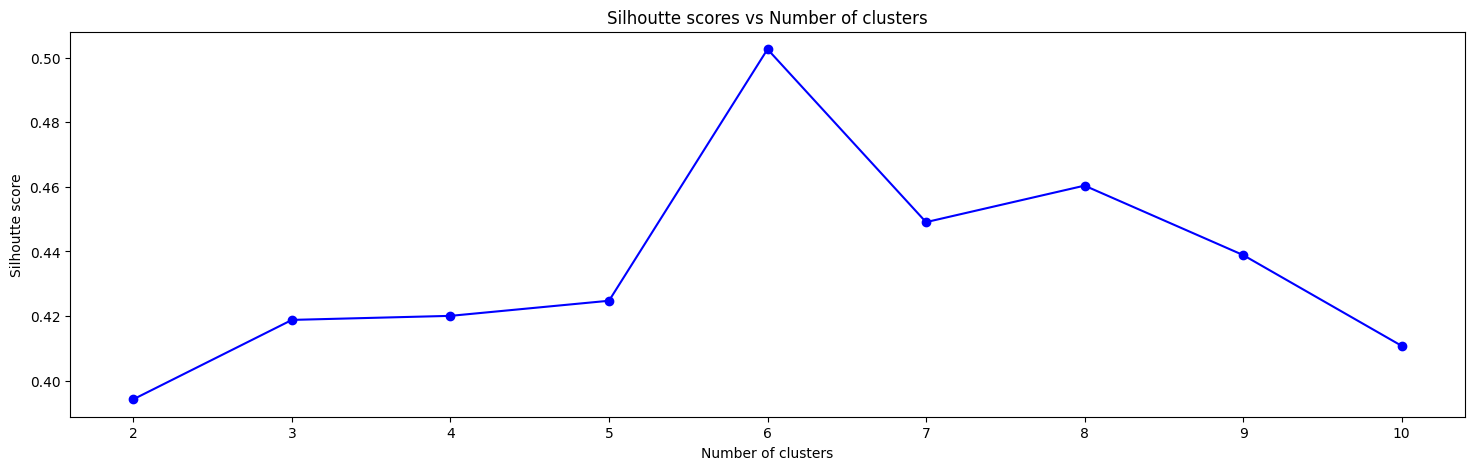

In [26]:
from sklearn.metrics import silhouette_score

plt.figure(figsize=(18,5))
silhoutte_scores = [silhouette_score(df_new, model.labels_) for model in kmeans_models[1:]]
plt.plot(range(2,11), silhoutte_scores, "bo-")
plt.title('Silhoutte scores vs Number of clusters')
plt.xlabel('Number of clusters')
plt.ylabel('Silhoutte score')
plt.show()

In [27]:
silhoutte_scores

[np.float64(0.39424205768375176),
 np.float64(0.41880405837590656),
 np.float64(0.4200573423620358),
 np.float64(0.4247344084832682),
 np.float64(0.5026204845335798),
 np.float64(0.4490762182551099),
 np.float64(0.46038325962755944),
 np.float64(0.43888700631390015),
 np.float64(0.4107759453745289)]

<h4><font face=verdona><hr>As per visualization and for little more depth in customer segmentation 4 clusters would be optimal <hr>

<center><h1><font face=georgia color=magenta> Cluster Model Building (1)</font><hr>

In [42]:
df_new.drop(columns=['KMC_clusters'], inplace=True)

In [ ]:
kmeans = KMeans(n_clusters=6, n_init='auto',init='k-means++', random_state=42, max_iter=100)
y_kmeans = kmeans.fit_predict(df_new)
df_new['KMC_clusters'] = y_kmeans

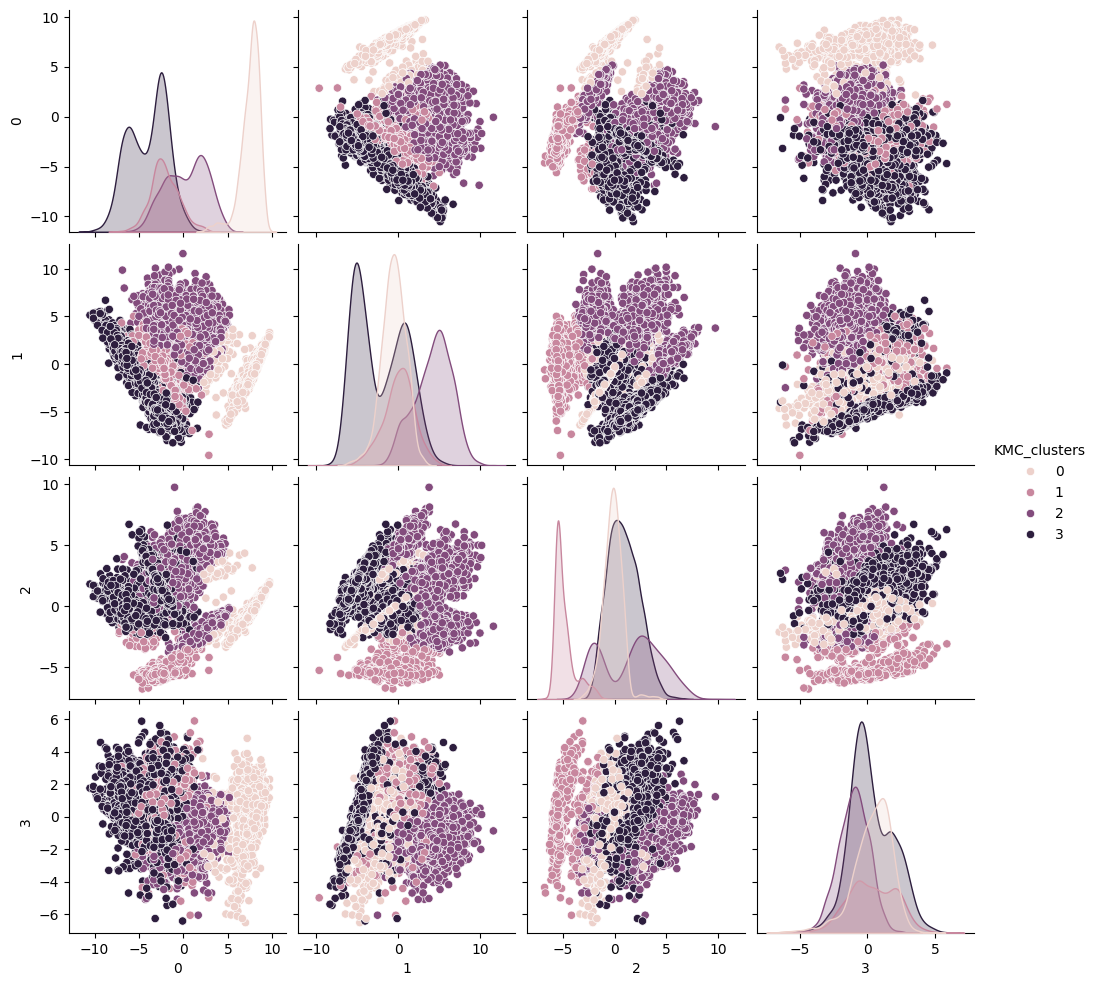

In [44]:
sns.pairplot(data=df_new, hue='KMC_clusters')
plt.show()

In [45]:
log_transformed_df['KMC_clusters'] = y_kmeans
log_transformed_df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,KMC_clusters
0,3.735304,0.597837,4.568506,0.000000,4.568506,0.000000,0.154151,0.000000,0.080042,0.000000,0.000000,1.098612,6.908755,5.312231,4.945277,0.000000,2.564949,3
1,8.071989,0.646627,0.000000,0.000000,0.000000,8.770896,0.000000,0.000000,0.000000,0.223144,1.609438,0.000000,8.853808,8.319725,6.978531,0.200671,2.564949,0
2,7.822504,0.693147,6.651791,6.651791,0.000000,0.000000,0.693147,0.693147,0.000000,0.000000,0.000000,2.564949,8.922792,6.434654,6.442994,0.000000,2.564949,1
4,6.707735,0.693147,2.833213,2.833213,0.000000,0.000000,0.080042,0.080042,0.000000,0.000000,0.000000,0.693147,7.090910,6.521114,5.504483,0.000000,2.564949,1
5,7.501540,0.693147,7.196147,0.000000,7.196147,0.000000,0.510826,0.000000,0.459532,0.000000,0.000000,2.197225,7.496097,7.244983,7.786654,0.000000,2.564949,3


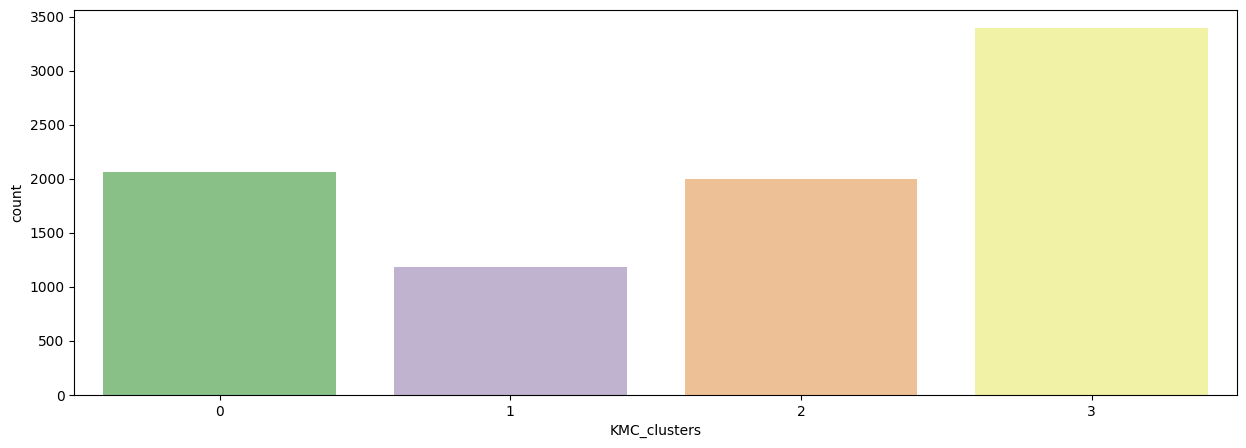

In [46]:
plt.figure(figsize=(15,5))
sns.countplot(x=log_transformed_df['KMC_clusters'], palette='Accent')
plt.show()

In [ ]:
scatter_plot = go.Scatter3d(
    x=df_new[0],
    y=df_new[0],
    z=df_new[0],
    marker=dict(
        color=log_transformed_df['KMC_clusters'], 
        colorscale='Viridis', 
        size=5, 
        opacity=0.8
    )
)

fig = go.Figure(data=[scatter_plot])
pio.write_image(fig, 'kmc_clusters_3d.png', format="png")

#as the angle of viewing on initial plot was not efficient to view all clusters, I had to manually 
#take screen schots of the graphy after rotating and zooming a bit

display(Image(filename='kmc_clusters_3d.png'))

ValueError: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido


<h4><font face=verdona><hr>Silhouette score (1)<hr>
to measure how well the data points can be differenciated from other clusters as well as how they can be categorized in their own cluster

In [47]:
silhouette_score(df_new, y_kmeans)

np.float64(0.43539487139417427)

<h4><font face=verdona><hr>Dendogram(Heirarchial Clustering)<hr>
to get the optimal number of clusters

In [ ]:
pca2 = PCA(n_components=num_components)

pca_df_ = pca2.fit_transform(data_new)
df_new_ = pd.DataFrame(pca_df_)
df_new_.head()

,0,1,2,3
0,-1.131391,-5.638595,0.437543,-0.501883
1,8.794180,1.315369,0.903667,0.783105
2,-2.468392,1.561188,-4.918480,2.475433
3,1.080909,-2.505522,-3.924572,2.183300
4,-3.266490,-2.807996,3.897840,3.193681


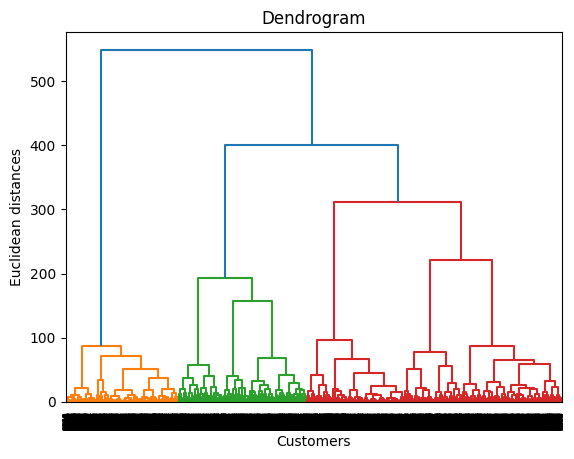

In [ ]:
dendogram = sch.dendrogram(sch.linkage(pca_df_, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

<h4><font face=verdona><hr>According to the dendogram the longest line with no other line intervening it directs us for 2 cluster but still for little more depth i will have 4 clusters.<hr>

<center><h1><font face=georgia color=magenta> Cluster Model Building (2)</font><hr>

In [ ]:
agc = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
y_agc = agc.fit_predict(df_new_)

In [ ]:
log_transformed_df['Agc_clusters'] = y_agc
log_transformed_df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,KMC_clusters,Agc_clusters
0,3.735304,0.597837,4.568506,0.000000,4.568506,0.000000,0.154151,0.000000,0.080042,0.000000,0.000000,1.098612,6.908755,5.312231,4.945277,0.000000,2.564949,5,1
1,8.071989,0.646627,0.000000,0.000000,0.000000,8.770896,0.000000,0.000000,0.000000,0.223144,1.609438,0.000000,8.853808,8.319725,6.978531,0.200671,2.564949,0,3
2,7.822504,0.693147,6.651791,6.651791,0.000000,0.000000,0.693147,0.693147,0.000000,0.000000,0.000000,2.564949,8.922792,6.434654,6.442994,0.000000,2.564949,1,0
4,6.707735,0.693147,2.833213,2.833213,0.000000,0.000000,0.080042,0.080042,0.000000,0.000000,0.000000,0.693147,7.090910,6.521114,5.504483,0.000000,2.564949,1,0
5,7.501540,0.693147,7.196147,0.000000,7.196147,0.000000,0.510826,0.000000,0.459532,0.000000,0.000000,2.197225,7.496097,7.244983,7.786654,0.000000,2.564949,5,1


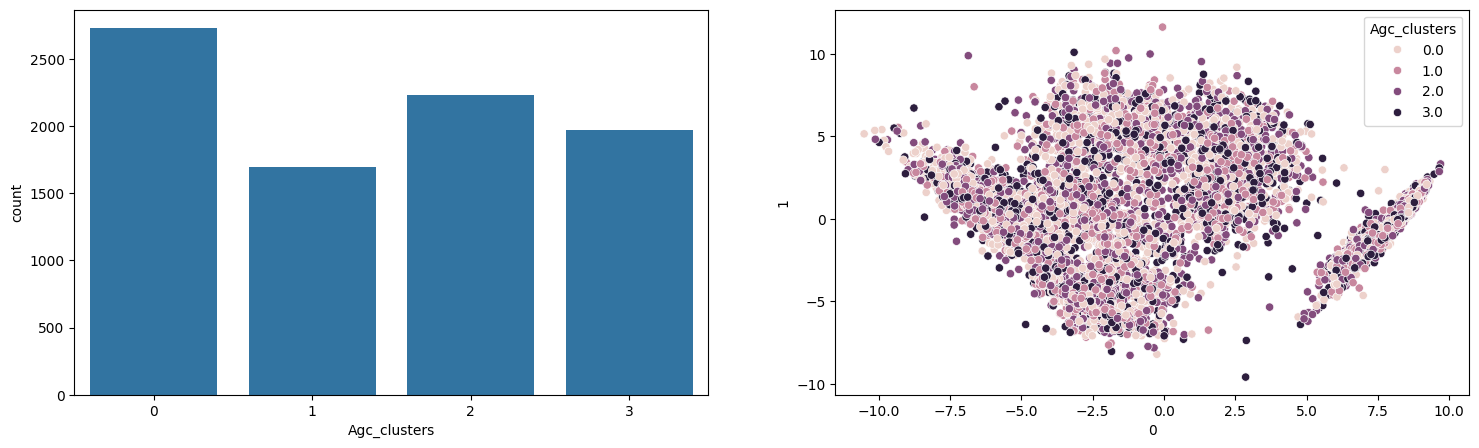

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(18,5))
axes = ax.flatten()
sns.countplot(x=log_transformed_df['Agc_clusters'], ax=ax[0])
sns.scatterplot(x=df_new_[0], y=df_new_[1], hue=log_transformed_df['Agc_clusters'], ax=ax[1])
plt.show()

<h4><font face=verdona><hr>Silhouette score (2)<hr>
Silhouette score closer to 1 indicates clusters are far away from each other and easily seperaple but in real world problems
    its never like that, as seen here the points are close to each other

In [ ]:
silhouette_score(df_new_, y_agc)

In [ ]:
scatter_plot = go.Scatter3d(
    x=df_new_[0],
    y=df_new_[0],
    z=df_new_[0],
    marker=dict(
        color=log_transformed_df['Agc_clusters'],  
        colorscale='Viridis',
        size=5,
        opacity=0.8
    )
)

fig = go.Figure(data=[scatter_plot])
# pio.write_image(fig, 'agc_clusters_3d.png', format="png")
display(Image(filename='agc_clusters_3d.png'))

<h4><font face=verdona><hr>Comparing Clusters of both the Models<hr>

In [ ]:
sns.countplot(x=log_transformed_df['Agc_clusters'], hue=log_transformed_df['KMC_clusters'])

<h4><font face=verdona><hr>The cluster 0 of Agc_clusters and cluster 3 of KMC_clusters seem to group mostly the same customers, while cluster 1 of Agc_clusters and cluster 0 of KMC_clusters and cluster 1 of Agc_clusters with that of cluster 2 and cluster 2 of KMC_clusters and cluster 4 of Agc_clusters matches cluster 1 of KMC_clusters .(cluster number is not the same but the each cluster of Agc_clusters represent some cluster of KMC_clusters)
<hr>
<pre>Therefore 
    cluster 0 of Agc_clusters ~ cluster 3 of KMC_clusters
    cluster 1 of Agc_clusters ~ cluster 0 of KMC_clusters    
    cluster 2 of Agc_clusters ~ cluster 2 of KMC_clusters
    cluster 3 of Agc_clusters ~ cluster 1 of KMC_clusters    

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15,5))
axes = ax.flatten()
for index, col in enumerate(log_transformed_df.columns[-2:]):
    axes[index].set_title(f'{col} - Cluster Distribution')
    axes[index].pie(x=log_transformed_df[col].value_counts(),
        labels =log_transformed_df[col].value_counts().index[:], autopct='%.2f%%' )
plt.show()

<h4><font face=verdona><hr>Now I can visualize are the features' range that differenciate between clusters<hr>

In [ ]:
fig, ax = plt.subplots(ncols=3, nrows=round((len(log_transformed_df.columns)+1)/3),
                       figsize=(18,5*round((len(log_transformed_df.columns)+1)/3)))
axes = ax.flatten()

for index, col in enumerate(log_transformed_df.columns):
    sns.histplot(x=log_transformed_df[col], hue=log_transformed_df['Agc_clusters'], kde=True, ax=axes[index],
                 hue_order=[3, 2,1,0],palette=['orange', 'r', 'b', 'g'])

In [ ]:
fig, ax = plt.subplots(ncols=3, nrows=round((len(log_transformed_df.columns)+1)/3), figsize=(18,5*round((len(log_transformed_df.columns)+1)/3)))
axes = ax.flatten()

for index, col in enumerate(log_transformed_df.columns):
    sns.histplot(x=log_transformed_df[col], hue=log_transformed_df['KMC_clusters'], kde=True, ax=axes[index],
                 hue_order=[3, 2,1,0],palette=['g','r','orange', 'b'])

<h3><font color=red 
          face=verdona><center>Since KMC_clusters have a better silhoutte score and Also majorly the cluster are the same,<br>
I will consider KMC_clusters as the target feature generated by KMeans

In [ ]:
log_transformed_df.drop(columns=['Agc_clusters'], inplace=True)

<center><font color=magenta face=georgia><h1>Cluster based EDA

<h4><font face=verdona><hr>As I havent droppend any rows the indices remain the same as raw data thus can assign the clusters to the original data

In [ ]:
df['KMC_clusters'] = log_transformed_df['KMC_clusters']
df.head()

In [ ]:
fig, ax = plt.subplots(ncols=3, nrows=round((len(df.columns)+1)/3), figsize=(18,5*round((len(df.columns)+1)/3)))
axes = ax.flatten()

for index, col in enumerate(df.columns):
    sns.boxplot(x=df['KMC_clusters'], y=df[col], ax=axes[index])

In [ ]:
fig, ax = plt.subplots(ncols=3, nrows=round((len(df.columns)+1)/3), figsize=(18,5*round((len(df.columns)+1)/3)))
axes = ax.flatten()

for index, col in enumerate(df.columns):
    sns.scatterplot(data=df, x='KMC_clusters', y=col, ax=axes[index], hue='KMC_clusters', palette=['red', 'green', 'blue', 'yellow'])

In [ ]:
for cluster in df.drop(['KMC_clusters'],axis=1):
    grid= sns.FacetGrid(df, col='KMC_clusters')
    grid= grid.map(sns.kdeplot, cluster)
plt.show()

<h4>Seperating different clusters data to understand the data better

In [ ]:
cluster_1_df = df[df["KMC_clusters"]==0]
cluster_2_df = df[df["KMC_clusters"]==1]
cluster_3_df = df[df["KMC_clusters"]==2]
cluster_4_df = df[df["KMC_clusters"]==3]

num_rows = round((len(df.columns) + 1) / 3)
num_cols = 3

fig, ax = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(18, 3 * num_rows))
axes = ax.flatten()

clusters = [cluster_1_df, cluster_2_df, cluster_3_df,cluster_4_df]
colors = ['r','g', 'b', 'orange']
for index, col in enumerate(df.columns):
    for cluster_index, cluster_df in enumerate(clusters):
        axes[index].axvline(cluster_df[col].median(), c=colors[cluster_index],
                            label=f'Cluster {cluster_index + 1}', linestyle='-')
    axes[index].set_xlabel(col)
    axes[index].legend()
plt.suptitle('Where does the median lie in each cluster ?', font='georgia', fontsize=30, y=1)
plt.tight_layout()
plt.show()

In [ ]:
len(cluster_1_df)



<pre><h1><font color=orange>============Cluster based Observations===========
</font>
Cluster 0:</h1>

This is the second largest cluster with 1316 customers.
Customers in this cluster have a relatively "higher average balance" (mean of 1937.19) and make moderate to high-value
purchases.
They have a mix of one-off and installment purchases.
Cash advance usage is moderate.
They tend to make purchases frequently.
They have a moderate credit limit.
Payments made are relatively high compared to the minimum payments.
They don't fully pay their balance (PRC_FULL_PAYMENT is relatively low).

<h2>Potential schemes to attract Cluster 0 customers:</h2>

Offer cashback or rewards on frequent purchases to encourage them to spend more.
Promote credit limit increases to boost their purchasing power.
Introduce installment purchase plans for high-value items.

<h1>Cluster 1:</h1>
This cluster is the largest with 7430 customers.
Customers in this cluster have a lower average balance (mean of 1439.13) and tend to make smaller purchases.
One-off purchases are infrequent, and installment purchases are also relatively low.
Cash advance usage is significant in this cluster.
They make purchases less frequently compared to Cluster 0.
Credit limits are moderate.
Payments and minimum payments are relatively low.
Most customers in this cluster don't fully pay their balances too(PRC_FULL_PAYMENT is low).

<h2>Potential schemes to attract Cluster 1 customers:</h2>
Offer incentives or discounts on cash advances to encourage usage.
Provide financial management tools and guidance to help them improve their payment behavior.
Introduce budget-friendly purchase options and promotions.

<h1>Cluster 2:</h1>
This cluster is the smallest with only 22 customers.
Customers in this cluster have a high average balance (mean of 5728.55) and make very high-value purchases.
They have a high frequency of purchases and one-off purchases.
Cash advance usage is low.
They tend to make purchases frequently and have a high credit limit.
Payments made are substantial compared to minimum payments.
Most customers in this cluster fully pay their balances (PRC_FULL_PAYMENT is high).

<h2>Potential schemes to attract Cluster 2 customers:</h2>
Offer premium rewards and exclusive benefits for high-value customers.
Provide personalized concierge services or exclusive offers.
Focus on credit limit increases for even larger purchases.
Offer investment or savings products to make use of their high balances.

<h1>Cluster 3:</h1>
This cluster consists of 182 customers being the second smallest cluster.
Customers in this cluster have a moderate average balance (mean of 3483.39) and make moderately high-value purchases.
They have a mix of one-off and installment purchases.
Cash advance usage is moderate.
They make purchases frequently.
Credit limits are moderate.
Payments made are decent compared to minimum payments.
Like Cluster 0, they don't fully pay their balances (PRC_FULL_PAYMENT is relatively low).

<h2>Potential schemes to attract Cluster 3 customers:</h2>
Offer rewards or discounts for frequent shoppers.
Encourage the use of credit cards for purchases through promotions.
Provide budgeting tools to help customers manage their payments better.


I have saved this content into cluster_info.txt so can access it in my web 